In [ ]:
# 노트북이 코랩에서 실행 중인지 체크합니다.

import sys
if 'google.colab' in sys.modules:
  !echo 'debconf debconf/frontend select Noniteractive' | \
  debconf-set-selections

  # 나눔 폰트를 설치합니다.
  !sudo apt-get -qq -y install fonts-nanum
  import matplotlib.font_manager as fm
  font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
  for fpath in font_files:
    fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Noniteractive
debconf: (Can't locate Debconf/FrontEnd/Noniteractive.pm in @INC (you may need to install the Debconf::FrontEnd::Noniteractive module) (@INC contains: /etc/perl /usr/local/lib/x86_64-linux-gnu/perl/5.34.0 /usr/local/share/perl/5.34.0 /usr/lib/x86_64-linux-gnu/perl5/5.34 /usr/share/perl5 /usr/lib/x86_64-linux-gnu/perl-base /usr/lib/x86_64-linux-gnu/perl/5.34 /usr/share/perl/5.34 /usr/local/lib/site_perl) at (eval 17) line 2, <> line 1.)
debconf: falling back to frontend: Noninteractive
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['figure.dpi']=100

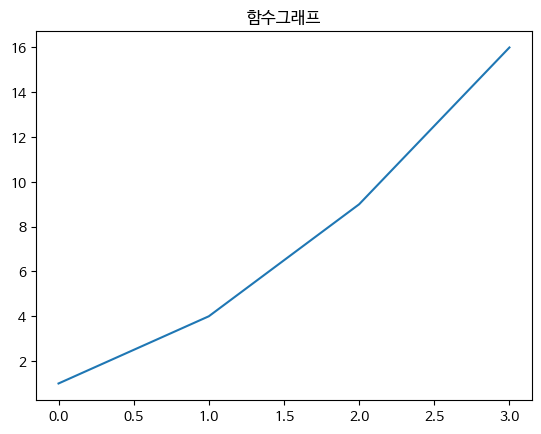

In [ ]:
plt.plot([1,4,9,16])
plt.title('함수그래프')
plt.show()

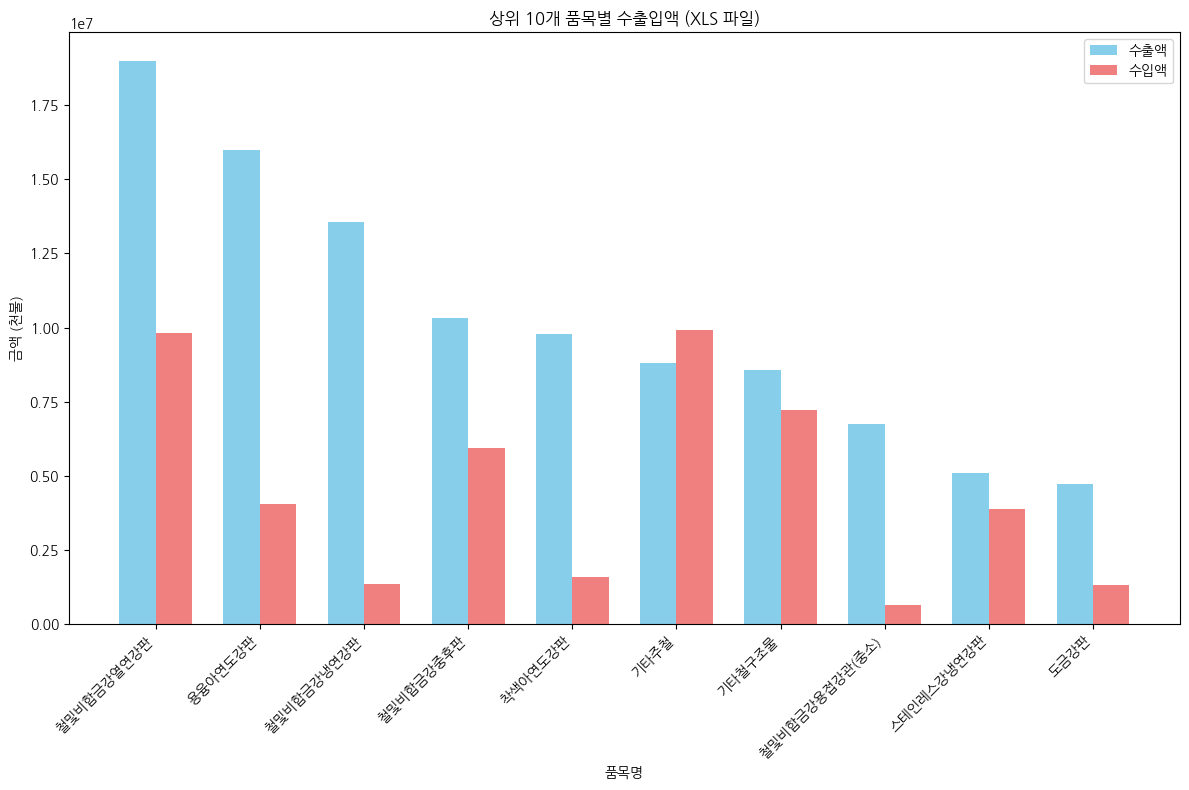

그래프가 'export_import_visualization_xls.png' 파일로 저장되었습니다.

상위 10개 품목 데이터:
               품목명       수출액      수입액
1       철및비합금강열연강판  19001017  9824654
2          용융아연도강판  15970301  4060907
3       철및비합금강냉연강판  13558798  1362945
4        철및비합금강중후판  10335754  5949821
5          착색아연도강판   9794100  1591963
6             기타주철   8820858  9901852
7           기타철구조물   8575626  7206023
8   철및비합금강용접강관(중소)   6762041   657757
9       스테인레스강냉연강판   5083554  3887672
10            도금강판   4739141  1312692


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정을 위해 NanumGothic을 사용합니다.
# 시스템에 폰트가 설치되어 있어야 합니다.
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 파일 경로를 지정해주세요.
file_path = '/content/drive/MyDrive/품목 수출입 총괄 _ 맞춤통계분석 - K-stat 수출입 무역통계 (2).xls'

try:
    # Excel 파일을 읽어옵니다. 'sheet1' 시트를 사용하고, 상위 3줄은 건너뜁니다.
    df = pd.read_excel(file_path, sheet_name='sheet1', skiprows=3)

    # 열 이름을 설정합니다.
    df.columns = ['순번', '코드', '품목명', '수출액', '수출_평균증감률', '수출_중량', '수입액', '수입_평균증감률', '수입_중량', '수지']

    # '총계'가 포함된 첫 번째 행을 제거합니다.
    df = df.drop(df.index[0])

    # 숫자 형태의 열들을 숫자 타입으로 변환합니다.
    numeric_cols = ['수출액', '수출_중량', '수입액', '수입_중량', '수지']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # '품목명', '수출액', '수입액'에 결측치가 있는 행을 제거합니다.
    df.dropna(subset=['품목명', '수출액', '수입액'], inplace=True)

    # 수출액을 기준으로 상위 10개 품목을 선택합니다.
    df_top10 = df.sort_values(by='수출액', ascending=False).head(10)

    # 시각화를 위한 그래프를 생성합니다.
    plt.figure(figsize=(12, 8))
    bar_width = 0.35
    index = np.arange(len(df_top10))

    plt.bar(index, df_top10['수출액'], bar_width, label='수출액', color='skyblue')
    plt.bar(index + bar_width, df_top10['수입액'], bar_width, label='수입액', color='lightcoral')

    plt.xlabel('품목명')
    plt.ylabel('금액 (천불)')
    plt.title('상위 10개 품목별 수출입액 (XLS 파일)')
    plt.xticks(index + bar_width / 2, df_top10['품목명'], rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 그래프를 이미지 파일로 저장합니다.
    plt.savefig('export_import_visualization_xls.png')

    print("그래프가 'export_import_visualization_xls.png' 파일로 저장되었습니다.")
    print("\n상위 10개 품목 데이터:")
    print(df_top10[['품목명', '수출액', '수입액']])

except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {file_path}")
except Exception as e:
    print(f"오류가 발생했습니다: {e}")

